## Cervical Cancer - benchmark of classification models

### The purpose of this notebook is to compare several supervised ML methods for the prediction of biopsy outcome, such as : logistic regression, random forests tree, XG boost and SVM.

Two predition settings are considered : 
1. Risk factors only
2. Risk factors + screening tests (Citology, Hinselmann, Schiller)

### 1. Import libraries + clean data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, precision_score
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

CLEAN_DIR = Path("../01_DATA/processed")
PLOTS_DIR = Path("../04_FIGURES")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path("../05_RESULTS")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CLEAN_DIR/"cervical_cancer_final.csv")
print("starting shape:", df.shape)

starting shape: (835, 32)


### 2. Definition of the target and prediction scenarios

In [67]:
target = "Biopsy"

screening_tests = ["Hinselmann", "Schiller", "Citology"]

y = df[target]

#Scenario 1 : Prediction from risk factors only
X_risk = df.drop(columns=[target] + screening_tests)
#Scenario 2 : Prediction including screening tests
X_full = df.drop(columns=[target])

print("Risk-factor dataset :", X_risk.shape)
print("Full dataset :", X_full.shape)

Risk-factor dataset : (835, 28)
Full dataset : (835, 31)


In [68]:
class_counts = y.value_counts().sort_index()
class_proportions = y.value_counts(normalize=True).sort_index()

print(class_counts)
print(class_proportions*100)

Biopsy
0    781
1     54
Name: count, dtype: int64
Biopsy
0    93.532934
1     6.467066
Name: proportion, dtype: float64


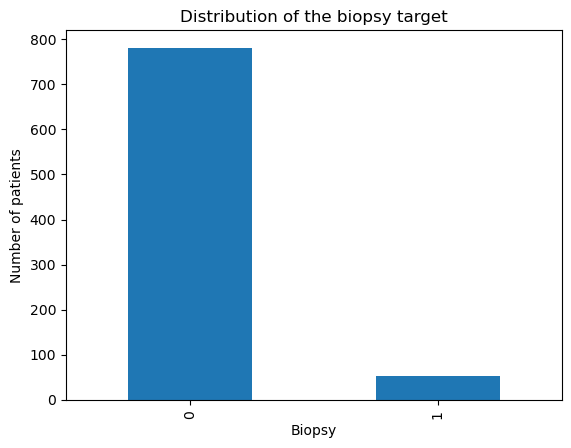

In [69]:
class_counts.plot(kind="bar")
plt.title("Distribution of the biopsy target")
plt.xlabel("Biopsy")
plt.ylabel("Number of patients")
#plt.grid()
plt.savefig(PLOTS_DIR / "biopsy_target_distribution.png")
plt.show()

### 3. Cross-validation + models tests parameters + scoring

In [70]:
RANDOM_STATE = 28 #random state added to make reproctubility possible, and use the same random state in every tests
cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 5, random_state = RANDOM_STATE)

Repeated stratified 5-fold was used to preserve the proportion of positive and negative biopsy outcome in each fold and to obtain a more robust estimate of model performance.

In [ ]:
models = {"Dummy": DummyClassifier(strategy = "prior", random_state = RANDOM_STATE),
          "Logistic Regression": Pipeline([("scaler", StandardScaler()),("classifier", LogisticRegression(class_weight = "balanced", max_iter = 5000, random_state = RANDOM_STATE))]),
          "Random Forest": RandomForestClassifier(n_estimators=300, class_weight = "balanced", random_state = RANDOM_STATE),
          "SVM": Pipeline([("scaler", StandardScaler()), ("classifier", SVC(kernel = "rbf", class_weight = "balanced", random_state = RANDOM_STATE))]),
          "XGBoost": XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, scale_pos_weight=(y == 0).sum() / (y == 1).sum(), random_state=RANDOM_STATE)}

For Logistic Regression and SVM, as they need to be standardized, we use Pipeline for that.

In [72]:
scoring = {"PR_AUC": "average_precision",
           "ROC_AUC": "roc_auc",
           "Recall": "recall",
           "Precision": make_scorer(precision_score, zero_division = 0), #to avoid having warnings output when the model predicts no positive
           "F1": "f1",
           "Balanced_accuracy": "balanced_accuracy"}

In [ ]:
def benchmark_models(X, y, models, cv, scoring):
    results = []
    for model_name, model in models.items():
        scores = cross_validate(model, X, y, cv = cv, scoring = scoring)
        row = {"Model": model_name}
        for metric in scoring:
            values = scores[f"test_{metric}"]
            row[f"{metric}_mean"] = values.mean()
            row[f"{metric}_std"] = values.std()
            row[f"{metric}_median"] = np.median(values)
            row[f"{metric}_min"] = values.min()
            row[f"{metric}_max"] = values.max()
        results.append(row)
    return pd.DataFrame(results)

We make a loop to test all the models at once and to keep the code as clean and concise as possible.

### 4. Benchmark (1) - Risk factors only

In [74]:
results_risk = benchmark_models(X_risk, y, models, cv, scoring)
results_risk.round(3)

results_risk.to_csv(RESULTS_DIR / "benchmark_risk_factors.csv", index=False)

### 5. Benchmark (2) - Risk factors + Screening tests

In [75]:
results_full = benchmark_models(X_full, y, models, cv, scoring)
results_full.round(3)

results_full.to_csv(RESULTS_DIR / "benchmark_all_features.csv", index=False)

The baseline classifier (Dummy) failed to identify positive biopsy cases in several validation folds, illustrating the limitations of threshold-based metrics in this highly imbalanced dataset.

PR-AUC remains particularly useful here because it utilizes scores/probabilities across all thresholds, rather than relying solely on a classification threshold like 0.5. That is precisely why it can be choosed as the primary metric.

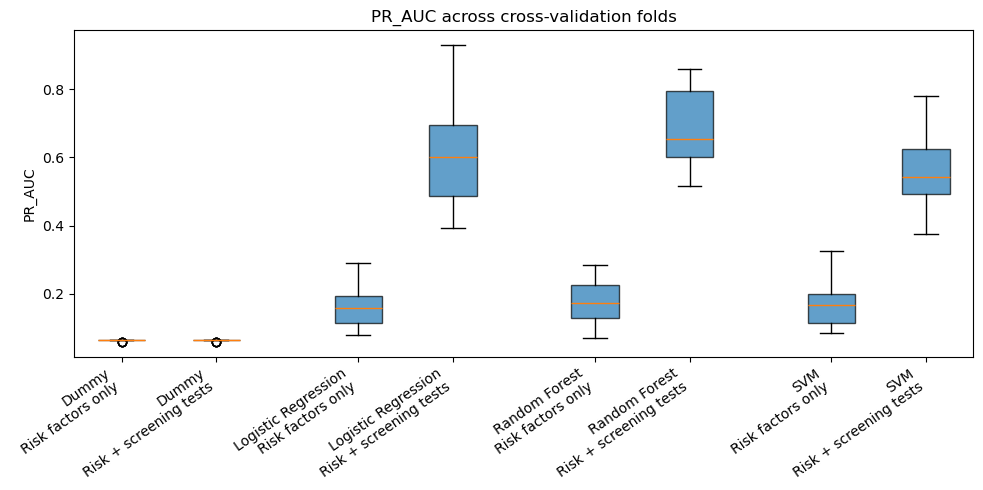

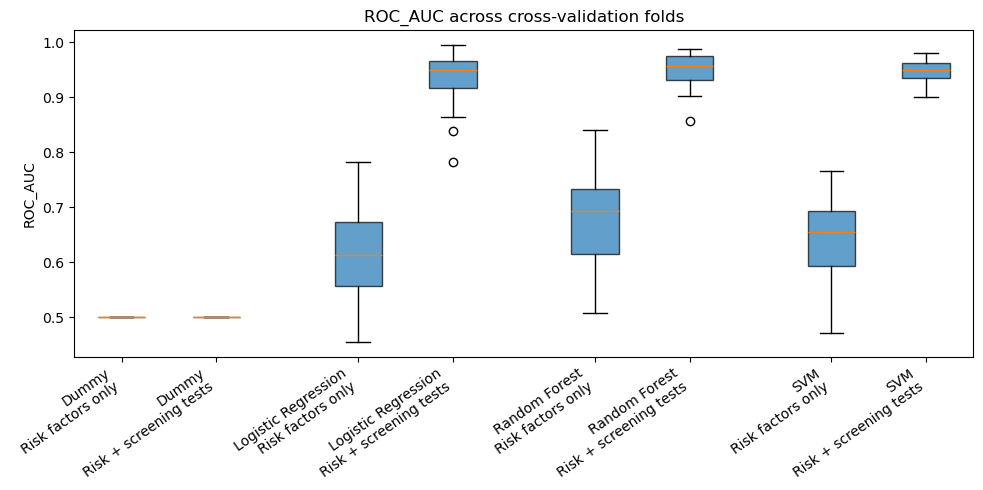

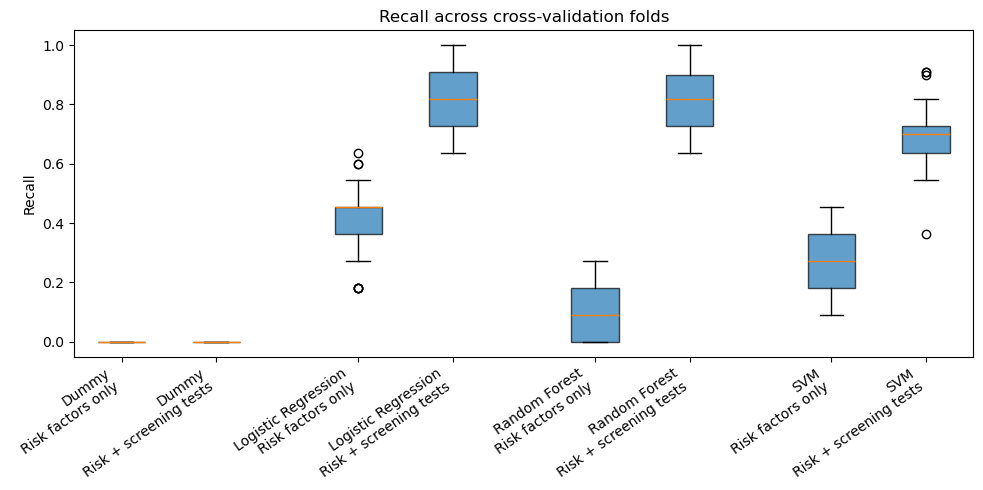

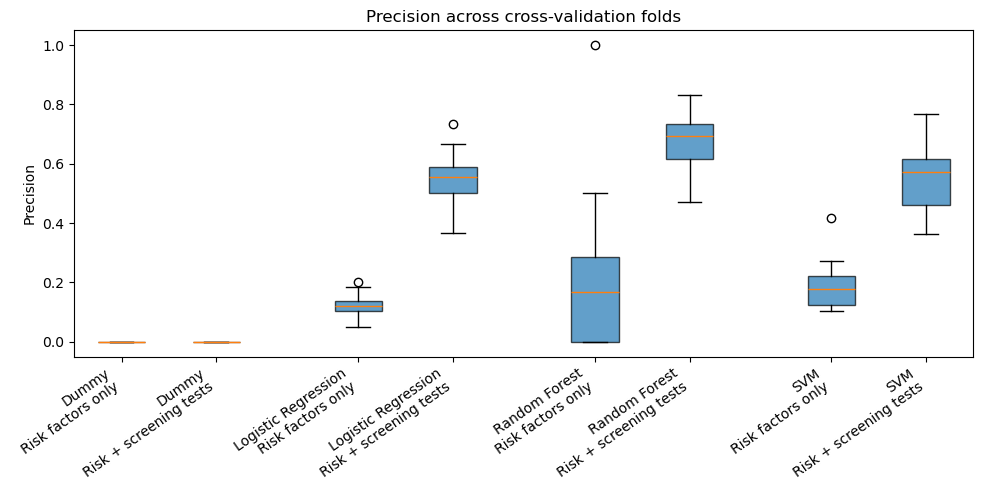

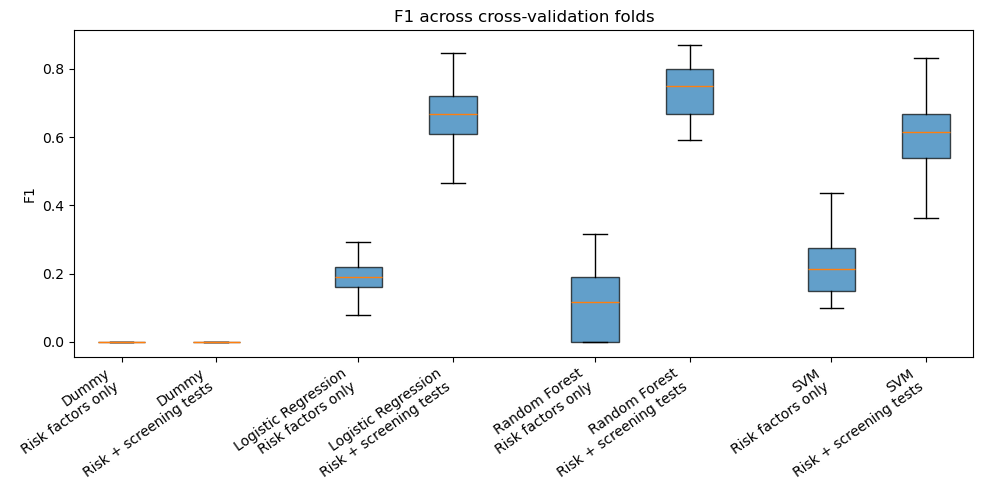

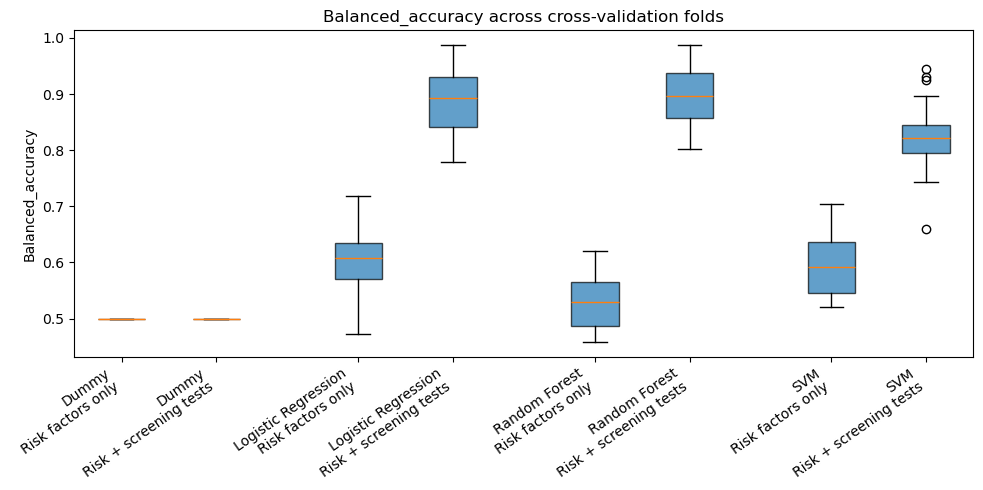

In [79]:
datasets = {"Risk factors only": X_risk, "Risk + screening tests": X_full}

all_scores = []

for scenario, X in datasets.items():
    for model_name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
        for metric in scoring:
            for value in scores[f"test_{metric}"]:
                all_scores.append({"Scenario": scenario, "Model": model_name, "Metric": metric, "Score": value})

scores_df = pd.DataFrame(all_scores)

summary = (scores_df.groupby(["Scenario", "Metric", "Model"])["Score"].agg(["mean", "std", "median", "min", "max"]).round(3))
summary
summary.to_csv(RESULTS_DIR / "benchmark_summary_all_metrics.csv")

for metric in scoring:
    data = scores_df[scores_df["Metric"] == metric]
    fig, ax = plt.subplots(figsize=(10, 5))
    positions = []
    values = []
    labels = []

    pos = 1

    for model in data["Model"].unique():
        for scenario in data["Scenario"].unique():

            vals = data.loc[
                (data["Model"] == model) &
                (data["Scenario"] == scenario),
                "Score"
            ].values

            values.append(vals)
            positions.append(pos)
            labels.append(f"{model}\n{scenario}")

            pos += 1

        pos += 0.5

    bp = ax.boxplot(
        values,
        positions=positions,
        patch_artist=True
    )

    for box in bp["boxes"]:
        box.set_alpha(0.7)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=35, ha="right")

    ax.set_title(f"{metric} across cross-validation folds")
    ax.set_ylabel(metric)

    plt.tight_layout()

    plt.savefig(
        PLOTS_DIR / f"{metric}_boxplot_risk_vs_full.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()